In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sb
import SensoriMotorPrediction.globals as gl
import PcmPy as pcm
import pandas as pd
from SensoriMotorPrediction.vis import plot_rdm
import nibabel as nb

Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/
Atlases dir found: atlases


# Average betas (example participant)

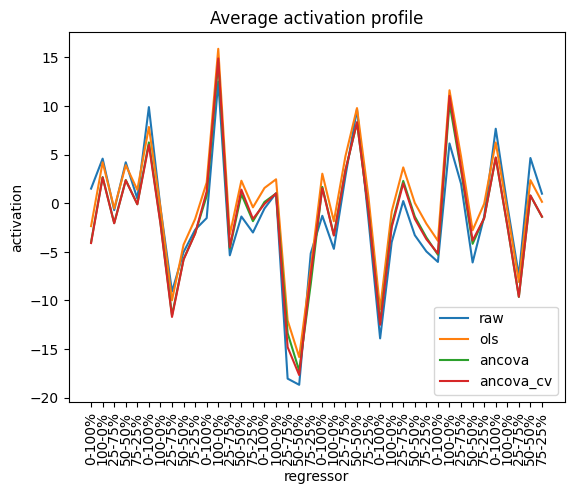

In [2]:
glm = 16
sn = 102
experiment = 'smp2'

B = nb.load(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', f'beta.dscalar.nii'))

reginfo = pd.read_csv(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', f'subj{sn}_reginfo.tsv'), sep='\t')
reginfo.name = reginfo.name.str.replace(' ', '')
reginfo['BN'] = reginfo['run']
tmp = reginfo['name'].str.split(',', expand=True)
reginfo['cue'] = tmp[0]

data = B.get_fdata()[reginfo.name.isin(gl.cues)]

B_ols = nb.load(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', f'beta.ols.dscalar.nii'))
data_ols = B_ols.get_fdata()

B_ancova = nb.load(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', f'beta.ancova.dscalar.nii'))
data_ancova = B_ancova.get_fdata()

B_ancova_cv = nb.load(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', f'beta.ancova_cv.dscalar.nii'))
data_ancova_cv = B_ancova_cv.get_fdata()

plt.plot(np.nanmean(data,axis=1), label='raw')
plt.plot(np.nanmean(data_ols, axis=1), label='ols')
plt.plot(np.nanmean(data_ancova, axis=1), label='ancova')
plt.plot(np.nanmean(data_ancova_cv, axis=1), label='ancova_cv')
plt.legend()
plt.ylabel('activation')
plt.xlabel('regressor')
labels = reginfo.cue[reginfo.name.isin(gl.cues)]
plt.xticks(range(len(labels)), labels, rotation=90)
plt.title('Average activation profile')
plt.show()

# Raw disimilarities

Mean crossnobis dissimilarity against 0 (one-sided t-test):
SMA: tval=2.164199146488875, pval=0.024825486982829666
PMd: tval=4.001272903935592, pval=0.0007542298155766069
PMv: tval=3.554106177981126, pval=0.0017642778458149444
M1: tval=4.198985530252177, pval=0.0005207634764951628
S1: tval=4.679053917584281, pval=0.00021561721380236707
SPLa: tval=6.848949532017808, pval=5.8608795789972164e-06
SPLp: tval=4.746287379067999, pval=0.00019098789628770174


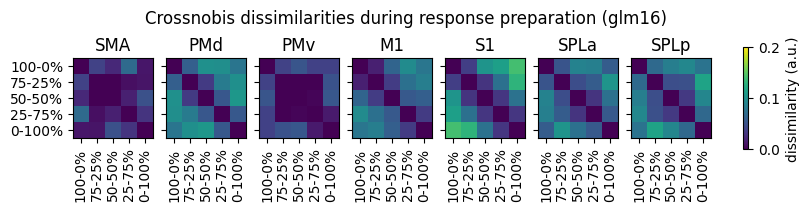

In [3]:
H = 'L'
rois = gl.rois['ROI']
glm = 16
vmin, vmax = 0, .2
fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
print('Mean crossnobis dissimilarity against 0 (one-sided t-test):')
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    plot_rdm(fig, axs, r, D, ['100-0%', '75-25%', '50-50%', '25-75%', '0-100%'], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle(f'Crossnobis dissimilarities during response preparation (glm{glm})')
fig.savefig(os.path.join('figures', f'crossnobis.plan.glm{glm}.pdf'))
plt.show()

# Pre-activation regressed out

### Using OLS

Mean crossnobis dissimilarity against 0 (one-sided t-test):
SMA: tval=0.7749645452431012, pval=0.2261134985983358
PMd: tval=2.815786269877652, pval=0.007291127927561343
PMv: tval=0.937092652527438, pval=0.18289729322566994
M1: tval=2.744420404964382, pval=0.00835753917781262
S1: tval=3.0217402793065973, pval=0.00490980070965781
SPLa: tval=4.354556713411924, pval=0.0003902003027380466
SPLp: tval=3.1554478186313455, pval=0.003795797402716654


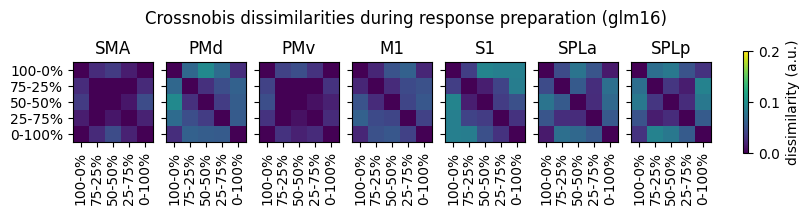

In [4]:
fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
print('Mean crossnobis dissimilarity against 0 (one-sided t-test):')
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.ols.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    plot_rdm(fig, axs, r, D, ['100-0%', '75-25%', '50-50%', '25-75%', '0-100%'], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle(f'Crossnobis dissimilarities during response preparation (glm{glm})')
#fig.savefig(os.path.join('figures', f'crossnobis.plan.glm{glm}.pdf'))
plt.show()

### Using ANCOVA

Mean crossnobis dissimilarity against 0 (one-sided t-test):
SMA: tval=3.9540548797352812, pval=0.0008244369850083878
PMd: tval=4.082305344472668, pval=0.000647701560927464
PMv: tval=3.930990246832395, pval=0.0008611317379264368
M1: tval=5.506908843900673, pval=5.0478003891249505e-05
S1: tval=5.976297682553632, pval=2.310590659701574e-05
SPLa: tval=4.697325972431211, pval=0.00020861369031365042
SPLp: tval=3.9879109355730464, pval=0.000773451980255533


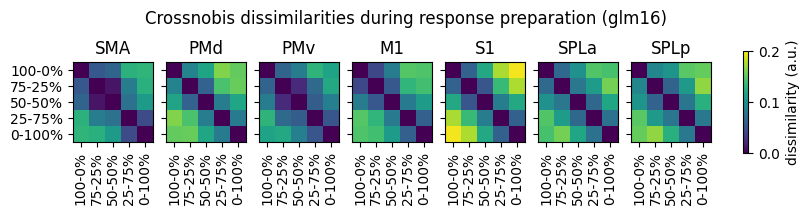

In [5]:
fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
print('Mean crossnobis dissimilarity against 0 (one-sided t-test):')
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.ancova.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    plot_rdm(fig, axs, r, D, ['100-0%', '75-25%', '50-50%', '25-75%', '0-100%'], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle(f'Crossnobis dissimilarities during response preparation (glm{glm})')
#fig.savefig(os.path.join('figures', f'crossnobis.plan.glm{glm}.pdf'))
plt.show()

### Using cross-validated ANCOVA

Mean crossnobis dissimilarity against 0 (one-sided t-test):
SMA: tval=3.252798181832593, pval=0.0031471215889798056
PMd: tval=3.580514582357903, pval=0.0016773039864534194
PMv: tval=3.1872559459862146, pval=0.0035703254485162416
M1: tval=5.003454443224205, pval=0.00012073793932371692
S1: tval=5.437671201050091, pval=5.679256670095395e-05
SPLa: tval=4.1356558087206245, pval=0.000586118776582263
SPLp: tval=3.595831656250486, pval=0.0016288643596635746


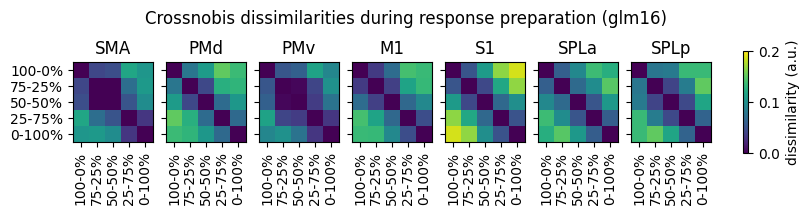

In [6]:
fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
print('Mean crossnobis dissimilarity against 0 (one-sided t-test):')
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.ancova_cv.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    plot_rdm(fig, axs, r, D, ['100-0%', '75-25%', '50-50%', '25-75%', '0-100%'], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle(f'Crossnobis dissimilarities during response preparation (glm{glm})')
#fig.savefig(os.path.join('figures', f'crossnobis.plan.glm{glm}.pdf'))
plt.show()

<Axes: xlabel='roi', ylabel='dissimilarity'>

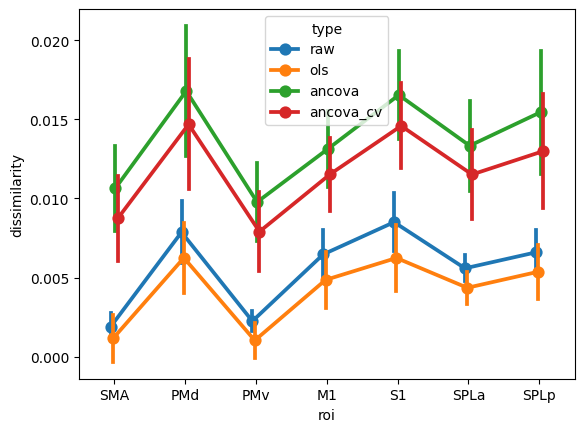

In [7]:
idx = np.triu_indices(5, k=1)
rows = []
for r, roi in enumerate(rois):
    G_raw = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    G_ols = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.ols.glm{glm}.{H}.{roi}.npy'))
    G_ancova = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.ancova.glm{glm}.{H}.{roi}.npy'))
    G_ancova_cv = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.ancova_cv.glm{glm}.{H}.{roi}.npy'))

    for s, sn in enumerate(gl.sns):
        D_raw = pcm.G_to_dist(G_raw[s])
        D_ols = pcm.G_to_dist(G_ols[s])
        D_ancova = pcm.G_to_dist(G_ancova[s])
        D_ancova_cv = pcm.G_to_dist(G_ancova_cv[s])
        rows.append({'sn': sn, 'dissimilarity': D_raw.mean(), 'roi': roi, 'type': 'raw'})
        rows.append({'sn': sn, 'dissimilarity': D_ols.mean(), 'roi': roi, 'type': 'ols'})
        rows.append({'sn': sn, 'dissimilarity': D_ancova.mean(), 'roi': roi, 'type': 'ancova'})
        rows.append({'sn': sn, 'dissimilarity': D_ancova_cv.mean(), 'roi': roi, 'type': 'ancova_cv'})

df = pd.DataFrame(rows)
fig, ax = plt.subplots()

sb.pointplot(data=df, ax=ax, y='dissimilarity', x='roi', hue='type', errorbar='se', dodge=True)


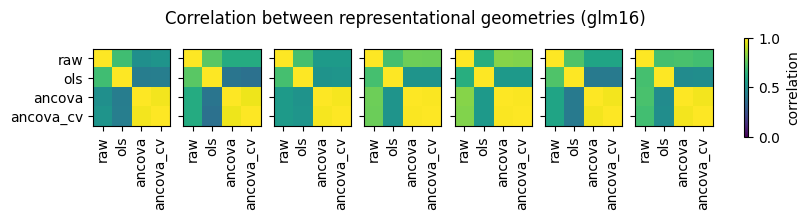

In [8]:
rows = []

idx = np.triu_indices(5, k=1)

fig, axs = plt.subplots(1, len(rois), figsize=(8, 2), sharex=True, sharey=True, constrained_layout=True)

for r, roi in enumerate(rois):
    G_raw = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    G_ols = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.ols.glm{glm}.{H}.{roi}.npy'))
    G_ancova = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.ancova.glm{glm}.{H}.{roi}.npy'))
    G_ancova_cv = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.ancova_cv.glm{glm}.{H}.{roi}.npy'))

    corr = np.zeros((len(gl.sns), 4, 4))
    for s, sn in enumerate(gl.sns):
        D_raw = pcm.G_to_dist(G_raw[s])[idx]
        D_ols = pcm.G_to_dist(G_ols[s])[idx]
        D_ancova = pcm.G_to_dist(G_ancova[s])[idx]
        D_ancova_cv = pcm.G_to_dist(G_ancova_cv[s])[idx]

        D = np.c_[D_raw, D_ols, D_ancova, D_ancova_cv]

        corr[s] = np.corrcoef(D.T)

    ax = axs[r]
    ax.imshow(corr.mean(axis=0), vmin=0, vmax=1, )
    ax.set_xticks(np.arange(4))
    ax.set_yticks(np.arange(4))
    ax.set_xticklabels(['raw', 'ols', 'ancova', 'ancova_cv'], rotation=90)
    ax.set_yticklabels(['raw', 'ols', 'ancova', 'ancova_cv'])

cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('correlation')
fig.suptitle(f'Correlation between representational geometries (glm{glm})')

plt.show()

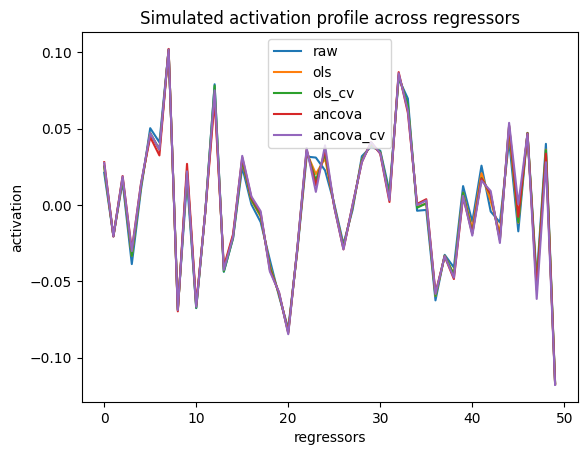

In [12]:
def ancova_regress_out_cv(B, F, Z, part_vec):
    n_f   = F.shape[1]
    B_res  = B.copy()

    for p in np.unique(part_vec):
        train = part_vec != p   # all partitions except p
        test  = part_vec == p   # partition p

        # Remove condition-mean structure from F in both sets
        F_train = F[train]
        F_test  = F[test]

        # Estimate W_F with OLS
        X_train = np.c_[F_train, Z[train]]
        W_train_ols = np.linalg.pinv(X_train) @ B[train]

        # Apply only F's contribution to the test partition
        B_res[test] = B[test] - F_test @ W_train_ols[:n_f]

    return B_res

def ols_regress_out_cv(B, F, part_vec):
    B_res = B.copy()

    for p in np.unique(part_vec):
        train = part_vec != p
        test  = part_vec == p

        # Estimate W_F on training partitions using F only
        W_train_ols = np.linalg.pinv(F[train]) @ B[train]

        # Apply to test partition
        B_res[test] = B[test] - F[test] @ W_train_ols

    return B_res

iterations = 100
r_FZ = 0.05  # correlation between F and condition membership
n_cond, n_part, n_vox, n_channel = 5, 10, 500, 1
n_obs = n_cond * n_part  # 50 = one obs per condition per partition

D, D_ols, D_ols_cv, D_ancova, D_ancova_cv  = [np.zeros(iterations) for _ in range(5)]

for i in range(iterations):

    rng = np.random.default_rng(i)

    # Each partition contains one observation per condition (like fMRI runs)
    cond_vec      = np.tile(np.arange(n_cond), n_part)   # [0,1,2,3,4, 0,1,2,3,4, ...]
    part_vec      = np.repeat(np.arange(n_part), n_cond)  # [0,0,0,0,0, 1,1,1,1,1, ...]

    Z = pcm.indicator(cond_vec)    # condition indicators (n_obs x n_cond)

    # B: true condition effects + noise
    B = rng.standard_normal((n_obs, n_vox))

    # F: one continuous regressor with controlled correlation to Z
    F_correlated = Z @ rng.standard_normal((n_cond, n_channel))  # condition-structured
    F_uncorrelated  = rng.standard_normal((n_obs, n_channel))   # random
    F = np.sqrt(r_FZ) * F_correlated + np.sqrt(1 - r_FZ) * F_uncorrelated  #/ F_noise.std(0)
    F = F - F.mean(axis=0, keepdims=True)

    # Simple regression out: project B onto null space of F
    B_ols = B - F @ np.linalg.pinv(F) @ B

    B_ols_cv = ols_regress_out_cv(B, F, part_vec)

    # ANCOVA: joint model [F, Z], remove only F's contribution
    W = np.linalg.pinv(np.c_[F, Z]) @ B
    B_ancova = B - F @ W[:n_channel]

    # ANCOVA: joint model [F, Z], remove only F's contribution in a cross-validated manner
    B_ancova_cv = ancova_regress_out_cv(B, F, Z, part_vec,)

    G, _ = pcm.est_G_crossval(B, cond_vec, part_vec, X=pcm.indicator(part_vec))
    D[i] = pcm.G_to_dist(G).mean()

    G_ols, _ = pcm.est_G_crossval(B_ols, cond_vec, part_vec, X=pcm.indicator(part_vec))
    D_ols[i] = pcm.G_to_dist(G_ols).mean()

    G_ols_cv, _ = pcm.est_G_crossval(B_ols_cv, cond_vec, part_vec, X=pcm.indicator(part_vec))
    D_ols_cv[i] = pcm.G_to_dist(G_ols_cv).mean()

    G_ancova, _ = pcm.est_G_crossval(B_ancova, cond_vec, part_vec, X=pcm.indicator(part_vec))
    D_ancova[i] = pcm.G_to_dist(G_ancova).mean()

    G_ancova_cv, _ = pcm.est_G_crossval(B_ancova_cv, cond_vec, part_vec, X=pcm.indicator(part_vec))
    D_ancova_cv[i] = pcm.G_to_dist(G_ancova_cv).mean()

plt.plot(B.mean(axis=1), label='raw')
plt.plot(B_ols.mean(axis=1), label='ols')
plt.plot(B_ols_cv.mean(axis=1), label='ols_cv')
plt.plot(B_ancova.mean(axis=1), label='ancova')
plt.plot(B_ancova_cv.mean(axis=1), label='ancova_cv')
plt.title('Simulated activation profile across regressors')
plt.ylabel('activation')
plt.xlabel('regressors')
plt.legend()
plt.show()

Text(0, 0.5, 'dissimilarity')

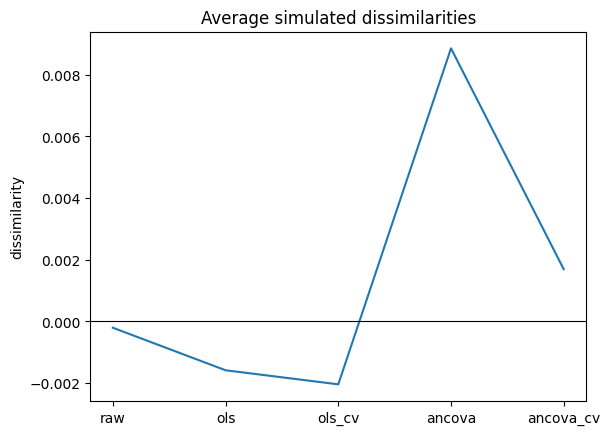

In [13]:
plt.plot(np.array([D.mean(), D_ols.mean(),D_ols_cv.mean(),  D_ancova.mean(), D_ancova_cv.mean(), ]))
ax = plt.gca()
ax.axhline(0, lw=.8, color='k')
ax.set_xticks(np.arange(5))
ax.set_xticklabels(['raw', 'ols','ols_cv', 'ancova', 'ancova_cv'])
ax.set_title('Average simulated dissimilarities')
ax.set_ylabel('dissimilarity')

# Forming matrices

## Notation

| Symbol | Dimensions | Description |
|--------|-----------|-------------|
| $\mathbf{Y}$ | $n \times p$ | data matrix ($n$ observations, $p$ voxels) |
| $\mathbf{F}$ | $n \times k$ | nuisance regressors to remove ($k$ channels) |
| $\mathbf{Z}$ | $n \times q$ | regressors of interest to preserve ($q$ conditions) |

---

## 1. Simple (OLS) regression out

**Goal:** remove all variance in $\mathbf{Y}$ that lies in the column space of $\mathbf{F}$.

**Step 1 — estimate coefficients** via OLS on $\mathbf{F}$ alone:

$$\hat{\mathbf{W}} = \mathbf{F}^+ \mathbf{Y} = (\mathbf{F}^\top\mathbf{F})^{-1}\mathbf{F}^\top \mathbf{Y}$$

**Step 2 — subtract the fitted values:**

$$\mathbf{Y}_\text{res} = \mathbf{Y} - \mathbf{F}\hat{\mathbf{W}} = \mathbf{Y} - \mathbf{F}\mathbf{F}^+\mathbf{Y}$$

**Step 3 — collect into the forming (residual-maker) matrix:**

$$\boxed{\mathbf{H}_\text{simple} = \mathbf{I} - \mathbf{F}\mathbf{F}^+}$$

so that $\mathbf{Y}_\text{res} = \mathbf{H}_\text{simple}\,\mathbf{Y}$.

> **Note:** $\mathbf{H}_\text{simple}$ is the orthogonal projector onto the null space of $\mathbf{F}$. It removes *all* variance shared between $\mathbf{F}$ and $\mathbf{Z}$, which biases the residuals if the two overlap.

---

## 2. ANCOVA

**Goal:** remove only $\mathbf{F}$'s *partial* contribution — the part orthogonal to $\mathbf{Z}$ — so that condition information in $\mathbf{Z}$ is not removed.

**Step 1 — build the joint design matrix:**

$$\mathbf{X} = [\mathbf{F} \;\; \mathbf{Z}] \quad (n \times (k+q))$$

**Step 2 — estimate all coefficients jointly:**

$$\hat{\mathbf{W}} = \mathbf{X}^+ \mathbf{Y} = \begin{bmatrix} \hat{\mathbf{W}}_F \\ \hat{\mathbf{W}}_Z \end{bmatrix}$$

where $\hat{\mathbf{W}}_F$ (first $k$ rows) are $\mathbf{F}$'s partial coefficients, accounting for the collinearity with $\mathbf{Z}$.

**Step 3 — subtract only $\mathbf{F}$'s contribution:**

$$\mathbf{Y}_\text{res} = \mathbf{Y} - \mathbf{F}\hat{\mathbf{W}}_F = \mathbf{Y} - \mathbf{F}\,\mathbf{e}_F\,\mathbf{X}^+\mathbf{Y}$$

where $\mathbf{e}_F = [\mathbf{I}_k \;\; \mathbf{0}]$ selects the first $k$ rows of $\mathbf{X}^+$.

**Step 4 — collect into the forming matrix:**

$$\boxed{\mathbf{H}_\text{ancova} = \mathbf{I} - \mathbf{F}\,\mathbf{e}_F\,[\mathbf{F}\;\mathbf{Z}]^+}$$

so that $\mathbf{Y}_\text{res} = \mathbf{H}_\text{ancova}\,\mathbf{Y}$.

> **Note:** When $\mathbf{F} \perp \mathbf{Z}$, the joint fit decouples and $\mathbf{H}_\text{ancova} = \mathbf{H}_\text{simple}$. When they overlap, ANCOVA removes *less* — only the unique variance of $\mathbf{F}$ — preserving the condition structure.


In [11]:
n_f = F.shape[1]
FZ  = np.c_[F, Z]

# e_F selects the first n_f rows of the joint pseudoinverse (F's block)
e_F = np.eye(FZ.shape[1])[:n_f]

H_simple = np.eye(len(F)) - F @ np.linalg.pinv(F)
H_ancova  = np.eye(len(F)) - F @ e_F @ np.linalg.pinv(FZ)

Y_res_simple = H_simple @ B
Y_res_ancova  = H_ancova  @ B

print('H_simple shape:', H_simple.shape)
print('H_ancova  shape:', H_ancova.shape)

assert np.allclose(Y_res_simple, B_simple), 'H_simple mismatch'
assert np.allclose(Y_res_ancova,  B_ancova),  'H_ancova mismatch'
print('Both forming matrices verified against the residuals.')


H_simple shape: (100, 100)
H_ancova  shape: (100, 100)


NameError: name 'B_simple' is not defined

## G matrix of the residuals

Given $\mathbf{G}_\mathbf{Y} = \mathbf{Y}\mathbf{Y}^\top$, the G matrix of the residuals $\mathbf{Y}_\text{res} = \mathbf{H}\mathbf{Y}$ follows directly:

$$\mathbf{G}_\text{res}
= \mathbf{Y}_\text{res}\mathbf{Y}_\text{res}^\top
= (\mathbf{H}\mathbf{Y})(\mathbf{H}\mathbf{Y})^\top
= \mathbf{H}\,\underbrace{\mathbf{Y}\mathbf{Y}^\top}_{\mathbf{G}_\mathbf{Y}}\,\mathbf{H}^\top
= \mathbf{H}\,\mathbf{G}_\mathbf{Y}\,\mathbf{H}^\top$$

### Case 1 — Simple ($\mathbf{H}_\text{simple}$)

$\mathbf{H}_\text{simple} = \mathbf{I} - \mathbf{F}\mathbf{F}^+$ is an **orthogonal projector**, hence symmetric ($\mathbf{H}^\top = \mathbf{H}$) and idempotent ($\mathbf{H}^2 = \mathbf{H}$). The formula simplifies to:

$$\boxed{\mathbf{G}_\text{res} = \mathbf{H}_\text{simple}\,\mathbf{G}_\mathbf{Y}\,\mathbf{H}_\text{simple}}$$

### Case 2 — ANCOVA ($\mathbf{H}_\text{ancova}$)

$\mathbf{H}_\text{ancova} = \mathbf{I} - \mathbf{F}\,\mathbf{e}_F\,[\mathbf{F}\;\mathbf{Z}]^+$ is **not symmetric** in general: its off-diagonal block mixes $\mathbf{F}$ and $\mathbf{Z}$, so $\mathbf{H}^\top \neq \mathbf{H}$ unless $\mathbf{F}\perp\mathbf{Z}$. The full form must be retained:

$$\boxed{\mathbf{G}_\text{res} = \mathbf{H}_\text{ancova}\,\mathbf{G}_\mathbf{Y}\,\mathbf{H}_\text{ancova}^\top}$$

> When $\mathbf{F}\perp\mathbf{Z}$ the two forming matrices coincide and both expressions give the same $\mathbf{G}_\text{res}$.


## Why is $\mathbf{G}_\text{true} = \mathbf{Z}\mathbf{U}\mathbf{U}^\top\mathbf{Z}^\top$?

It follows directly from the data model. The signal part of $\mathbf{Y}$ is $\mathbf{Z}\mathbf{U}$, and $\mathbf{G}$ is defined as the second moment $\mathbf{Y}\mathbf{Y}^\top$. Applied to the signal alone:

$$\mathbf{G}_\text{true} = (\mathbf{Z}\mathbf{U})(\mathbf{Z}\mathbf{U})^\top = \mathbf{Z}\mathbf{U}\mathbf{U}^\top\mathbf{Z}^\top$$

Each entry $(i,j)$ of this $n_\text{obs} \times n_\text{obs}$ matrix is the inner product between the signal for observation $i$ and observation $j$ across voxels:

$$(\mathbf{G}_\text{true})_{ij} = \mathbf{u}_{c(i)}^\top \mathbf{u}_{c(j)}$$

where $c(i)$ denotes the condition of observation $i$. Because $\mathbf{Z}$ is a condition indicator, the matrix is **block-structured**:

$$\mathbf{G}_\text{true} = \mathbf{Z}\,\underbrace{\mathbf{U}\mathbf{U}^\top}_{\mathbf{G}_\text{PCM}}\,\mathbf{Z}^\top$$

where $\mathbf{G}_\text{PCM}$ is the $n_\text{cond} \times n_\text{cond}$ condition-level G matrix — the quantity the crossvalidated estimator actually recovers. $\mathbf{G}_\text{true}$ is just $\mathbf{G}_\text{PCM}$ expanded into observation space via $\mathbf{Z}$: observations from the same condition share the same pattern, so all their pairwise inner products are identical.


## Analytical bias prediction via H

Having $\mathbf{H}$ in hand lets us predict *analytically* how each approach distorts $\mathbf{G}$, without running a simulation.

### Data model

Assume the data are generated as:

$$\mathbf{Y} = \mathbf{Z}\mathbf{U} + \mathbf{F}\mathbf{V} + \mathbf{E}$$

where $\mathbf{U}$ are the true condition patterns (signal of interest), $\mathbf{V}$ are the nuisance weights, and $\mathbf{E}$ is i.i.d. noise. The **true** G matrix we want to recover is:

$$\mathbf{G}_\text{true} = \mathbf{Z}\mathbf{U}\mathbf{U}^\top\mathbf{Z}^\top$$

### Step 1 — nuisance is nulled by construction

Both forming matrices satisfy $\mathbf{H}\mathbf{F} = \mathbf{0}$ (this follows directly from the definitions of $\mathbf{F}^+$ and $[\mathbf{F}\;\mathbf{Z}]^+$). Therefore:

$$\mathbf{H}\mathbf{Y} = \mathbf{H}\mathbf{Z}\mathbf{U} + \underbrace{\mathbf{H}\mathbf{F}}_{=\,\mathbf{0}}\mathbf{V} + \mathbf{H}\mathbf{E} = \mathbf{H}\mathbf{Z}\mathbf{U} + \mathbf{H}\mathbf{E}$$

The nuisance component $\mathbf{G}_F = \mathbf{F}\mathbf{V}\mathbf{V}^\top\mathbf{F}^\top$ is removed **exactly**. The residual bias depends entirely on how $\mathbf{H}$ acts on $\mathbf{Z}$.

### Step 2 — how does H act on Z?

#### Simple

Substitute the definition $\mathbf{H}_\text{simple} = \mathbf{I} - \mathbf{F}\mathbf{F}^+$ and expand:

$$\mathbf{H}_\text{simple}\mathbf{Z}
= (\mathbf{I} - \mathbf{F}\mathbf{F}^+)\mathbf{Z}
= \mathbf{Z} - \mathbf{F}\underbrace{\mathbf{F}^+\mathbf{Z}}_{\text{OLS fit of }\mathbf{Z}\text{ on }\mathbf{F}}$$

$\mathbf{F}^+\mathbf{Z}$ is the least-squares coefficient when regressing $\mathbf{Z}$ onto $\mathbf{F}$, and $\mathbf{F}\mathbf{F}^+\mathbf{Z}$ is the resulting fitted values — i.e. the part of $\mathbf{Z}$ that lives in the column space of $\mathbf{F}$. Whenever $\mathbf{F}$ and $\mathbf{Z}$ share variance, this is non-zero:

$$\mathbf{H}_\text{simple}\mathbf{Z} = \mathbf{Z} - \mathbf{F}\mathbf{F}^+\mathbf{Z} \;\equiv\; \tilde{\mathbf{Z}} \;\neq\; \mathbf{Z}$$

The condition structure is distorted by the amount $\mathbf{F}$ and $\mathbf{Z}$ overlap.

#### ANCOVA

Substitute $\mathbf{H}_\text{ancova} = \mathbf{I} - \mathbf{F}\,\mathbf{e}_F\,[\mathbf{F}\;\mathbf{Z}]^+$ and expand:

$$\mathbf{H}_\text{ancova}\mathbf{Z}
= \mathbf{Z} - \mathbf{F}\,\mathbf{e}_F\,[\mathbf{F}\;\mathbf{Z}]^+\mathbf{Z}$$

We need to evaluate $[\mathbf{F}\;\mathbf{Z}]^+\mathbf{Z}$. The key identity is:

$$[\mathbf{F}\;\mathbf{Z}]^+\,[\mathbf{F}\;\mathbf{Z}] = \mathbf{I}_{(n_F+n_Z)}$$

(pseudoinverse times matrix = identity, since $[\mathbf{F}\;\mathbf{Z}]$ has full column rank). Since $\mathbf{Z}$ is precisely the **last $n_Z$ columns** of $[\mathbf{F}\;\mathbf{Z}]$, right-multiplying by $\mathbf{Z}$ extracts the last $n_Z$ columns of the identity:

$$[\mathbf{F}\;\mathbf{Z}]^+\mathbf{Z} = \mathbf{e}_Z^\top = \begin{bmatrix}\mathbf{0}_{n_F\times n_Z}\\\mathbf{I}_{n_Z}\end{bmatrix}$$

Now apply $\mathbf{e}_F = [\mathbf{I}_{n_F}\;\mathbf{0}_{n_F\times n_Z}]$ (which selects the **first $n_F$ rows**):

$$\mathbf{e}_F\,[\mathbf{F}\;\mathbf{Z}]^+\mathbf{Z}
= \mathbf{e}_F\,\mathbf{e}_Z^\top
= [\mathbf{I}_{n_F}\;\mathbf{0}]\begin{bmatrix}\mathbf{0}\\\mathbf{I}_{n_Z}\end{bmatrix}
= \mathbf{0}_{n_F\times n_Z}$$

$\mathbf{e}_F$ picks the top block and $\mathbf{e}_Z^\top$ has zeros there, so the product is zero. Therefore:

$$\mathbf{H}_\text{ancova}\mathbf{Z} = \mathbf{Z} - \mathbf{F}\cdot\mathbf{0} = \mathbf{Z}$$

The ANCOVA forming matrix leaves $\mathbf{Z}$ **unchanged** — the condition structure is perfectly preserved.

### Step 3 — predicted G of the residuals

From Step 1 we have $\mathbb{E}[\mathbf{G}_\text{res}] = \mathbf{H}\,\mathbf{G}_\text{true}\,\mathbf{H}^\top$ (noise averages to zero). Substituting $\mathbf{G}_\text{true} = \mathbf{Z}\mathbf{U}\mathbf{U}^\top\mathbf{Z}^\top$:

$$\mathbb{E}[\mathbf{G}_\text{res}]
= \mathbf{H}\,(\mathbf{Z}\mathbf{U}\mathbf{U}^\top\mathbf{Z}^\top)\,\mathbf{H}^\top
= (\mathbf{H}\mathbf{Z})\,\mathbf{U}\mathbf{U}^\top\,(\mathbf{H}\mathbf{Z})^\top$$

So the expected G of the residuals has the same form as $\mathbf{G}_\text{true}$, but with $\mathbf{Z}$ replaced by $\mathbf{H}\mathbf{Z}$. Plugging in the results from Step 2:

**Simple** — replace $\mathbf{Z}$ with $\tilde{\mathbf{Z}} = \mathbf{H}_\text{simple}\mathbf{Z}$:

$$\mathbb{E}[\mathbf{G}_\text{res,simple}] = \tilde{\mathbf{Z}}\,\mathbf{U}\mathbf{U}^\top\,\tilde{\mathbf{Z}}^\top \;\neq\; \mathbf{G}_\text{true}$$

Because $\tilde{\mathbf{Z}}$ is $\mathbf{Z}$ with the part shared with $\mathbf{F}$ removed, conditions that differ mainly through $\mathbf{F}$-correlated activity will appear *more similar* than they truly are — the geometry is shrunk.

**ANCOVA** — replace $\mathbf{Z}$ with $\mathbf{H}_\text{ancova}\mathbf{Z} = \mathbf{Z}$:

$$\mathbb{E}[\mathbf{G}_\text{res,ancova}] = \mathbf{Z}\,\mathbf{U}\mathbf{U}^\top\,\mathbf{Z}^\top = \mathbf{G}_\text{true}$$

No bias. The condition structure is recovered exactly.

**The bias of the simple approach** is therefore:

$$\Delta\mathbf{G} = \mathbb{E}[\mathbf{G}_\text{res,simple}] - \mathbf{G}_\text{true}
= \tilde{\mathbf{Z}}\,\mathbf{U}\mathbf{U}^\top\,\tilde{\mathbf{Z}}^\top - \mathbf{Z}\,\mathbf{U}\mathbf{U}^\top\,\mathbf{Z}^\top$$

This is fully computable from $\mathbf{H}_\text{simple}$, $\mathbf{Z}$, and an estimate of $\mathbf{U}\mathbf{U}^\top$ (e.g. from the raw betas) — no simulation required.


## Why does ANCOVA inflate and OLS deflate crossvalidated dissimilarities?

### Setup

**Notation.** Let $i, j$ index conditions, $k, l$ index runs (partitions), and $\text{obs}(i,k)$ denote the observation of condition $i$ in run $k$. Assume $\mathbf{F} = \mathbf{Z}\boldsymbol{\alpha}$, so every run of condition $i$ has the same F-value $\alpha_i$. Noise $\boldsymbol{\varepsilon}$ is i.i.d. with variance $\sigma^2$ across observations and voxels.

### Step 1 — the cross-partition noise covariance

After applying $\mathbf{H}$, the residual noise for observation $k$ is the $k$-th row of $\mathbf{H}\boldsymbol{\varepsilon}$, which is $\sum_m H_{km}\boldsymbol{\varepsilon}_m$. The cross-partition noise covariance between observations $k$ and $l$ is:

$$\mathbb{E}\bigl[(\mathbf{H}\boldsymbol{\varepsilon})_k^\top(\mathbf{H}\boldsymbol{\varepsilon})_l\bigr]
= \sum_{m,n} H_{km}H_{ln}\underbrace{\mathbb{E}[\boldsymbol{\varepsilon}_m^\top\boldsymbol{\varepsilon}_n]}_{\sigma^2 n_\text{vox}\,\delta_{mn}}
= \sigma^2 n_\text{vox}\sum_m H_{km}H_{lm}
= \sigma^2 n_\text{vox}\,(\mathbf{H}\mathbf{H}^\top)_{kl}$$

The crossvalidated G is unbiased only if $(\mathbf{H}\mathbf{H}^\top)_{kl}=0$ for $k\neq l$. The **sign of $(\mathbf{H}\mathbf{H}^\top)_{kl}$** determines whether the estimator is inflated or deflated.

### Step 2 — OLS: $\mathbf{H}_\text{simple}\mathbf{H}_\text{simple}^\top = \mathbf{H}_\text{simple}$

$\mathbf{H}_\text{simple} = \mathbf{I} - \mathbf{P}_F$ is symmetric and idempotent, where $\mathbf{P}_F = \mathbf{F}(\mathbf{F}^\top\mathbf{F})^{-1}\mathbf{F}^\top$ is the projection onto $\mathbf{F}$'s column space. Therefore $\mathbf{H}\mathbf{H}^\top = \mathbf{H}^2 = \mathbf{H}$, so:

$$(\mathbf{H}_\text{simple}\mathbf{H}_\text{simple}^\top)_{\text{obs}(i,k),\,\text{obs}(j,l)} = -(\mathbf{P}_F)_{\text{obs}(i,k),\,\text{obs}(j,l)} = -\frac{\alpha_i\,\alpha_j}{\|\boldsymbol{\alpha}\|^2}$$

The dissimilarity $D_{ij} = G_{ii}+G_{jj}-2G_{ij}$ receives a noise bias from this term:

$$\text{bias}(D_{ij}) \propto -\frac{\alpha_i^2}{\|\boldsymbol{\alpha}\|^2} - \frac{\alpha_j^2}{\|\boldsymbol{\alpha}\|^2} + \frac{2\alpha_i\alpha_j}{\|\boldsymbol{\alpha}\|^2} = -\frac{(\alpha_i-\alpha_j)^2}{\|\boldsymbol{\alpha}\|^2} \leq 0$$

OLS always **deflates**: the bias is zero only when conditions $i$ and $j$ have equal F-values.

### Step 3 — ANCOVA: $\mathbf{H}_\text{ancova}\mathbf{H}_\text{ancova}^\top = \mathbf{H}_\text{ancova} + \boldsymbol{\Delta}$

$\mathbf{H}_\text{ancova} = \mathbf{I} - \mathbf{F}\mathbf{e}_F\mathbf{X}^+$ is idempotent but **not symmetric** (here $\mathbf{X}=[\mathbf{F}\;\mathbf{Z}]$ and $\mathbf{e}_F=[\mathbf{I}_{n_F}\;\mathbf{0}]$ selects F's block). Expanding $\mathbf{H}\mathbf{H}^\top$ using $\mathbf{H}^\top = \mathbf{I} - \mathbf{X}^{+\top}\mathbf{e}_F^\top\mathbf{F}^\top$ and $\mathbf{X}^+\mathbf{X}^{+\top} = (\mathbf{X}^\top\mathbf{X})^{-1}$:

$$\mathbf{H}\mathbf{H}^\top = \mathbf{H} + \underbrace{\mathbf{F}\mathbf{e}_F(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{e}_F^\top\mathbf{F}^\top}_{\boldsymbol{\Delta}\,\succeq\,0}$$

$\boldsymbol{\Delta}\succeq 0$ because it has the form $\mathbf{C}\mathbf{A}\mathbf{C}^\top$ with $\mathbf{A}=(\mathbf{X}^\top\mathbf{X})^{-1}\succ 0$. Its cross-partition entry is:

$$\boldsymbol{\Delta}_{\text{obs}(i,k),\,\text{obs}(j,l)} = \alpha_i^\top\,\mathbf{A}_F\,\alpha_j, \qquad \mathbf{A}_F = \mathbf{e}_F(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{e}_F^\top$$

The $\boldsymbol{\Delta}$ contribution to $D_{ij}$:

$$\text{extra bias}(D_{ij}) \propto \alpha_i^\top\mathbf{A}_F\alpha_i + \alpha_j^\top\mathbf{A}_F\alpha_j - 2\alpha_i^\top\mathbf{A}_F\alpha_j = (\alpha_i-\alpha_j)^\top\mathbf{A}_F(\alpha_i-\alpha_j) \geq 0$$

ANCOVA always **inflates**: the extra bias is zero only when conditions $i$ and $j$ have equal F-values.

### Conclusion

The key structural fact is that $\mathbf{H}_\text{simple}$ is an **orthogonal** projector ($\mathbf{H}\mathbf{H}^\top = \mathbf{H}$) while $\mathbf{H}_\text{ancova}$ is an **oblique** projector ($\mathbf{H}\mathbf{H}^\top = \mathbf{H} + \boldsymbol{\Delta}$). The extra PSD term $\boldsymbol{\Delta}$ is what turns deflation into inflation. Both biases vanish when $\alpha_i = \alpha_j$ (conditions $i$ and $j$ have the same F-value) and grow with $(\alpha_i-\alpha_j)^2$.


## Why does OLS give negative dissimilarities when F correlates with Z?

### The key property of OLS

When $\mathbf{F}$ is condition-structured ($\mathbf{F} = \mathbf{Z}\boldsymbol{\alpha}$), every run of condition $i$ has exactly the same F-value $\alpha_i$. The OLS slope $\hat{w}_F$ is estimated once from all runs together. The correction subtracted from condition $i$ in run $k$ is:

$$\text{correction for condition } i, \text{ run } k = \alpha_i \cdot \hat{w}_F$$

Because $\alpha_i$ does not depend on $k$, **this is the same value for every run**. In other words, OLS subtracts a fixed, run-independent shift from each condition. That shift is proportional to $\hat{w}_F$, which in turn is proportional to the average condition pattern across all runs. The residual is therefore:

$$\mathbf{B}_k^\text{res} = \mathbf{B}_k - \underbrace{\text{constant across runs}}_{ \boldsymbol{\alpha}\hat{w}_F} = \mathbf{B}_k - \bar{\mathbf{B}}_{\text{condition avg}}$$

What remains in each run is its **deviation from the cross-run mean**: how much run $k$'s condition pattern differs from the average across all runs.

### Why deviations give negative cross-run products

Deviations from a mean always sum to zero:

$$\sum_k \mathbf{B}_k^\text{res} = \mathbf{0}$$

This means if run 1 shows condition A higher than the mean, run 2 must compensate and show condition A **lower** than the mean. The two runs are forced to point in opposite directions.

The crossvalidated G is built from cross-run products $\mathbf{B}_k^\text{res}(\mathbf{B}_l^\text{res})^\top$ for $k \neq l$. Because the residuals are forced in opposite directions, these products are **negative** — and so are the dissimilarities.

> **In short:** OLS removes the average condition pattern from every run. What is left sums to zero across runs. Zero-summing quantities are always negatively correlated with each other, which makes the crossvalidated dissimilarities negative.


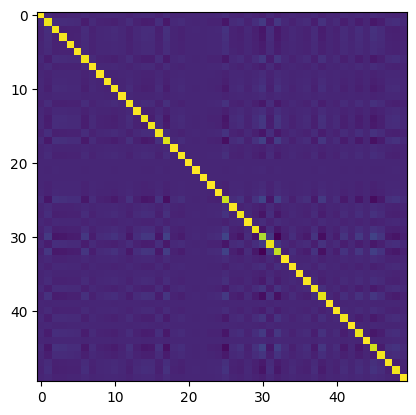

In [47]:
r_FZ = 1  # correlation between F and condition membership
n_cond, n_part, n_vox, n_channel = 5, 10, 500, 2
n_obs = n_cond * n_part  # 50 = one obs per condition per partition

rng = np.random.default_rng(0)

# Each partition contains one observation per condition (like fMRI runs)
cond_vec      = np.tile(np.arange(n_cond), n_part)   # [0,1,2,3,4, 0,1,2,3,4, ...]
part_vec      = np.repeat(np.arange(n_part), n_cond)  # [0,0,0,0,0, 1,1,1,1,1, ...]

Z = pcm.indicator(cond_vec)    # condition indicators (n_obs x n_cond)

# B: true condition effects + noise
B = rng.standard_normal((n_obs, n_vox))

# F: one continuous regressor with controlled correlation to Z
F_correlated = Z @ rng.standard_normal((n_cond, n_channel))  # condition-structured
F_uncorrelated  = rng.standard_normal((n_obs, n_channel))   # random
F = np.sqrt(r_FZ) * F_correlated + np.sqrt(1 - r_FZ) * F_uncorrelated  #/ F_noise.std(0)
F = F - F.mean(axis=0, keepdims=True)

H_ols = np.eye(n_obs) - F @ np.linalg.pinv(F)

plt.imshow(H_simple)

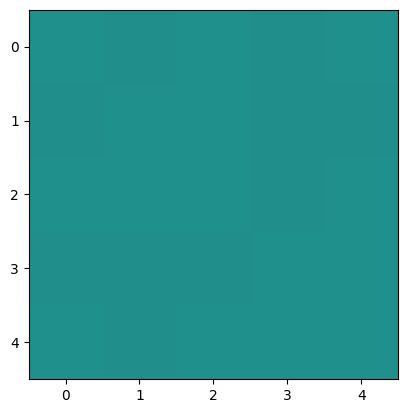

In [ ]:
G_full, _ = pcm.est_G_crossval(B, cond_vec, part_vec, X=pcm.indicator(part_vec))
D_full = pcm.G_to_dist(G_full)

plt.imshow(D_full, vmin=-100, vmax=100)


In [64]:
G_ols = H_ols @ G_full @ H_ols.T

plt.imshow(D_ols, vmin=-100, vmax=100)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 5 is different from 50)

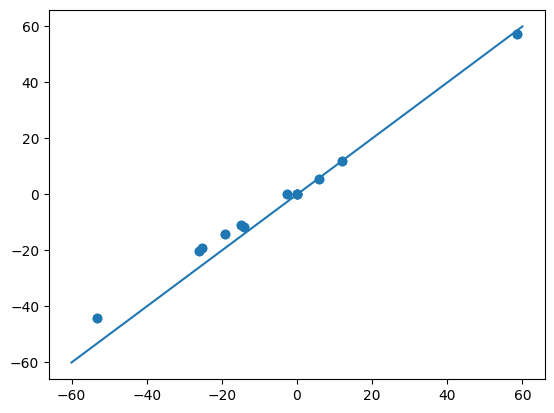

In [57]:
plt.scatter(D_raw_12.flatten(), D_ols_12.flatten())
plt.plot([-60, 60], [-60, 60])